In [2]:
# For using EigenMaps' SHAPIQ decompositon method. 

In [3]:
## Load cell 
import os, sys, pickle, importlib, numpy as np, pandas as pd

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
importlib.reload(eigen_steering)
eigen_steering.WEIGHTS_PATH = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/pytorch_base_model/model_fold_0.safetensors'
eigen_steering.RESULTS_DIR = os.path.join(REPO, 'models')
from eigen_steering import EigenMap

lib_path = os.path.join(REPO, 'virtual_perturbations', 'libraries', 'hippo_target_library.pkl')
with open(lib_path, 'rb') as f:
    lib = pickle.load(f)

df = lib['df']
focus_tfs = lib['focus_tfs']

# Build EigenMap — HepG2 first so it plots on top
CT = {'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
em = EigenMap(model_names=CT, device='cuda')

em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

# Build seq_idx -> raw npz index mapping (npz has all seq_valid rows,
# df used the additional keep filter dropping 3 rows)
raw = np.load(lib['attr_npz_path'])
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna()
n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
raw_indices = np.arange(n)[keep]  # filtered_idx -> raw npz idx
del df_full

ohe = em.X.numpy()
idxs = df.seq_idx.values
npz_idxs = raw_indices[idxs]  # correct mapping
for ct in CT:
    hyp = raw[f'attr_{ct}'][npz_idxs]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][npz_idxs]

em.motif_hits = lib['motif_hits']
em.eigen_results = lib['eigen_results']

print(f'Loaded {len(df)} sequences')
print(f'  Conditions: {df["condition"].value_counts().to_dict()}')
print(f'  Focus TFs: {len(focus_tfs)}')
print(f'  Cell type order: {em.cell_types} (top row first)')

AlphaGenome patches applied (all functional activations -> nn.Module).
EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
Loaded 1059 sequences, X shape: torch.Size([1059, 4, 281])
Loaded 1059 sequences
  Conditions: {'same-diff': 353, 'diff-diff': 353, 'same-same': 353}
  Focus TFs: 151
  Cell type order: ['HepG2', 'K562'] (top row first)


In [4]:
# Run necessity-mode SHAPIQ on all sequences
n_rep = 20
seed = 42
max_order = 6

sii_results = em.shapley_interaction_index(
    seq_idx=None, max_order=max_order,
    n_rep=n_rep, batch_size=516, random_state=seed,
)

# Collect into a flat dataframe
# results[si] = {annotation_ct: {motifs, interactions, coalition_values, n_motifs}}
rows = []
for si, res in enumerate(sii_results):
    if res is None:
        continue
    for act, act_res in res.items():  # act = annotation cell type
        if act_res['n_motifs'] == 0:
            continue
        motif_names = act_res['motifs']
        for interaction_key, ct_scores in act_res['interactions'].items():
            order = len(interaction_key)
            label = 'null syntax' if order == 0 else f'order {order}'
            names = '+'.join(motif_names[i] for i in interaction_key) if order > 0 else 'null'
            for ct, score in ct_scores.items():
                rows.append({
                    'seq_idx': si,
                    'annotation_ct': act,
                    'scoring_ct': ct,
                    'interaction': interaction_key,
                    'motif_names': names,
                    'order_label': label,
                    'order': order,
                    'sii_score': score,
                    'EI_1_vxr': df.iloc[si]['EI_1 var x r'],
                    'condition': df.iloc[si]['condition'],
                    'n_motifs': act_res['n_motifs'],
                })

sii_df = pd.DataFrame(rows)
print(f'{len(sii_df)} rows, {sii_df.seq_idx.nunique()} sequences')
print(f'Orders: {sii_df.order_label.value_counts().to_dict()}')
print(f'Annotation CTs: {sii_df.annotation_ct.value_counts().to_dict()}')

/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Loading HepG2: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/checkpoints/best_stage2.pt
  Loading K562: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/checkpoints/best_stage2.pt
  shapley (necessity): 1059/1059 sequences
10452 rows, 1059 sequences
Orders: {'order 1': 4704, 'null syntax': 3192, 'order 2': 1928, 'order 3': 502, 'order 4': 104, 'order 5': 20, 'order 6': 2}
Annotation CTs: {'HepG2': 6488, 'K562': 3964}


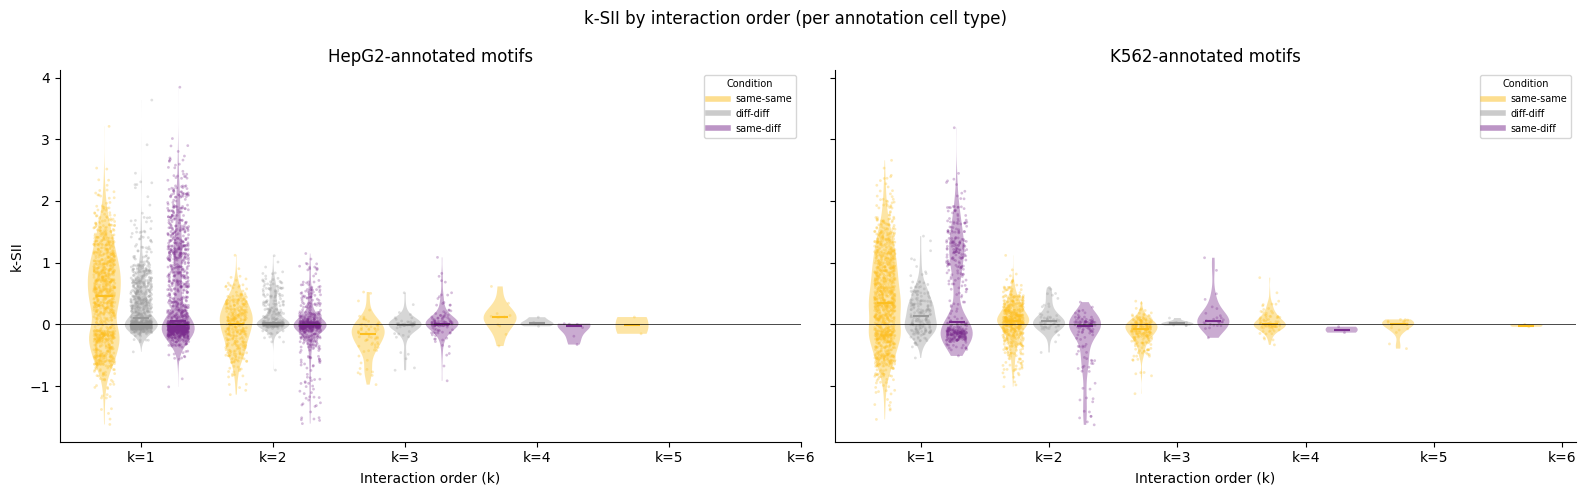

In [5]:
import matplotlib.pyplot as plt

# Plot per annotation cell type: each annotation's motifs scored by both models
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
orders = sorted(sii_df[sii_df.order >= 1].order.unique())

cond_style = {
    'same-same': ('#fcbf20', -0.28, 'same-same'),
    'diff-diff': ('#999999', 0.0, 'diff-diff'),
    'same-diff': ('#7b2d8e', 0.28, 'same-diff'),
}

for ax_i, act in enumerate(em.cell_types):
    ax = axes[ax_i]
    sub_act = sii_df[(sii_df.annotation_ct == act) & (sii_df.order >= 1)]

    rng = np.random.default_rng(42)
    for cond, (color, xoff, label) in cond_style.items():
        sub = sub_act[sub_act.condition == cond]
        violin_data = []
        valid_positions = []
        for o in orders:
            vals = sub.loc[sub.order == o, 'sii_score'].values
            if len(vals) > 1:
                violin_data.append(vals)
                valid_positions.append(o + xoff)
        if violin_data:
            parts = ax.violinplot(
                violin_data, positions=valid_positions,
                widths=0.25, showmedians=True, showextrema=False,
            )
            for pc in parts['bodies']:
                pc.set_facecolor(color)
                pc.set_alpha(0.4)
            parts['cmedians'].set_color(color)
            parts['cmedians'].set_linewidth(1.5)
        for o in orders:
            vals = sub.loc[sub.order == o, 'sii_score'].values
            if len(vals) == 0:
                continue
            jit = rng.uniform(-0.08, 0.08, len(vals))
            ax.scatter(o + xoff + jit, vals, s=4, alpha=0.3,
                       color=color, edgecolors='none', zorder=2)
        ax.plot([], [], color=color, lw=4, alpha=0.5, label=label)

    ax.axhline(0, c='k', lw=0.5)
    ax.set_xticks(orders)
    ax.set_xticklabels([f'k={o}' for o in orders])
    ax.set_xlabel('Interaction order (k)')
    ax.set_title(f'{act}-annotated motifs')
    ax.legend(fontsize=7, title='Condition', title_fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('k-SII')
plt.suptitle('k-SII by interaction order (per annotation cell type)', fontsize=12)
plt.tight_layout()
plt.show()

## Context-aware SHAPIQ: background + promoter as players

In [24]:
# Run context-aware SHAPIQ: motifs + background + promoter as players
importlib.reload(eigen_steering)
eigen_steering.WEIGHTS_PATH = os.path.join(REPO, 'pytorch_base_model', 'model_fold_0.safetensors')
eigen_steering.RESULTS_DIR = os.path.join(REPO, 'models')
from eigen_steering import EigenMap

# rebuild em with reloaded module
em = EigenMap(model_names=CT, device='cuda')
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})
ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][npz_idxs]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][npz_idxs]
em.motif_hits = lib['motif_hits']
em.eigen_results = lib['eigen_results']

ctx_results = em.shapley_interaction_index_context(
    seq_idx=None, max_order=max_order,
    n_rep=n_rep, batch_size=516, random_state=seed,
)

# Collect into flat dataframe
ctx_rows = []
for si, res in enumerate(ctx_results):
    if res is None:
        continue
    for act, act_res in res.items():
        if act_res['n_players'] == 0:
            continue
        player_names = act_res['motifs']
        player_types = act_res['player_types']
        for interaction_key, ct_scores in act_res['interactions'].items():
            order = len(interaction_key)
            names = '+'.join(player_names[i] for i in interaction_key) if order > 0 else 'null'
            types_in = [player_types[i] for i in interaction_key] if order > 0 else ['null']
            types_set = set(types_in)
            if order == 0:
                itype = 'null'
            elif order == 1:
                t = types_in[0]
                itype = '1-motif' if t == 'motif' else t  # 'background' or 'promoter'
            else:
                n_motif = types_in.count('motif')
                has_bg = 'background' in types_set
                has_prom = 'promoter' in types_set
                if n_motif == 0:
                    itype = 'bg-prom'
                else:
                    suffix = ('-bg' if has_bg else '') + ('-prom' if has_prom else '')
                    itype = f'{n_motif}-motif{suffix}'
            for ct, score in ct_scores.items():
                ctx_rows.append({
                    'seq_idx': si,
                    'annotation_ct': act,
                    'scoring_ct': ct,
                    'interaction': interaction_key,
                    'player_names': names,
                    'order': order,
                    'itype': itype,
                    'sii_score': score,
                    'EI_1_vxr': df.iloc[si]['EI_1 var x r'],
                    'condition': df.iloc[si]['condition'],
                })

ctx_df = pd.DataFrame(ctx_rows)
print(f'{len(ctx_df)} rows, {ctx_df.seq_idx.nunique()} sequences')
print(f'Interaction types:\n{ctx_df.groupby(["order","itype"]).size().to_string()}')

EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
Loaded 1059 sequences, X shape: torch.Size([1059, 4, 281])
  Loading HepG2: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/checkpoints/best_stage2.pt
  Loading K562: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/checkpoints/best_stage2.pt
  shapley context (necessity): 1059/1059 sequences
45945 rows, 1059 sequences
Interaction types:
order  itype          
0      null               4236
1      1-motif            4704
       background         4236
       promoter           4236
2      1-motif-bg         4701
       1-motif-prom       4704
       2-motif            1927
       bg-prom            4236
3      1-motif-bg-prom    4704
       2-motif-bg         1926
       2-motif-prom       1928
       3-motif             500
4      2-motif-bg-prom    1928
       3-motif-bg          497


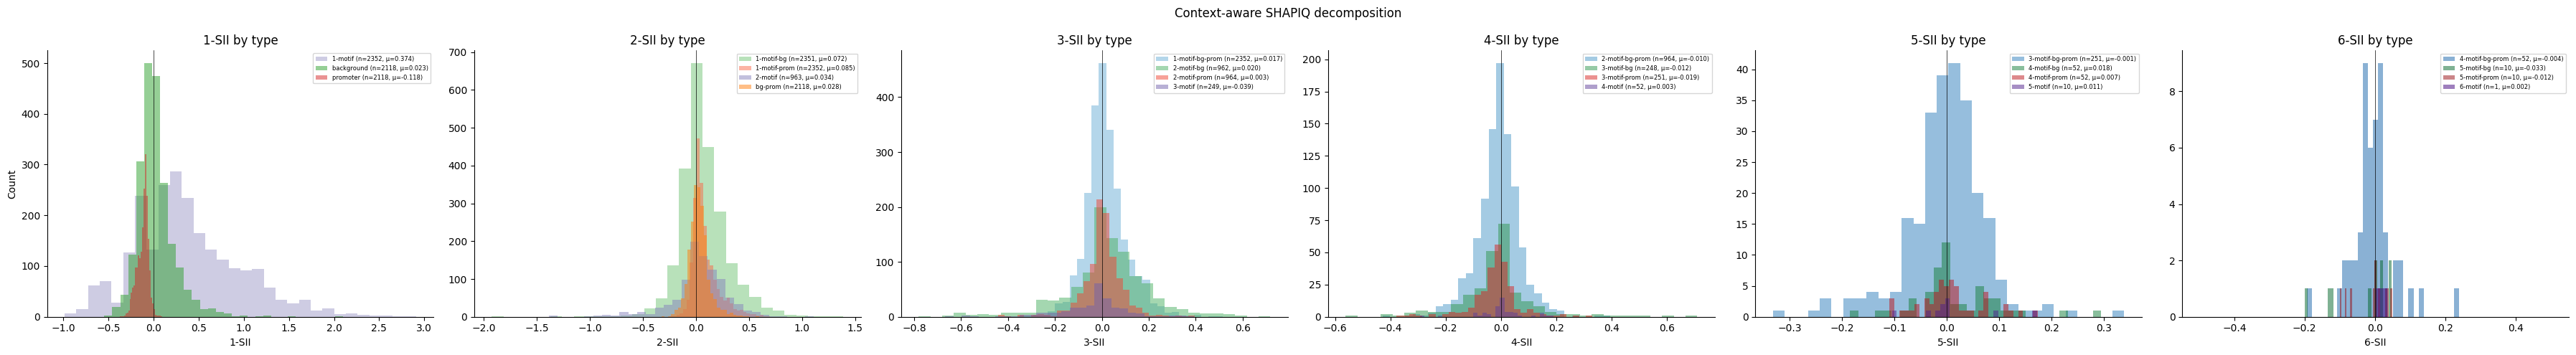

In [25]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def itype_color(itype):
    """Color by interaction family; shade by motif count."""
    if itype in ('null', 'background'):
        return '#2ca02c'
    if itype == 'promoter':
        return '#d62728'
    if itype == 'bg-prom':
        return '#ff7f0e'
    # format: '{n}-motif[suffix]'  e.g. '2-motif-bg-prom'
    parts = itype.split('-', 2)   # ['n', 'motif', 'suffix'] or ['n', 'motif']
    n = int(parts[0])
    suffix = parts[2] if len(parts) > 2 else ''
    intensity = 0.4 + n * 0.1    # 1→0.5 ... 6→1.0
    if suffix == '':
        return cm.Purples(intensity)
    elif suffix == 'bg':
        return cm.Greens(intensity)
    elif suffix == 'prom':
        return cm.Reds(intensity)
    else:                          # 'bg-prom'
        return cm.Blues(intensity)

diag = ctx_df[ctx_df.annotation_ct == ctx_df.scoring_ct]

fig, axes = plt.subplots(1, 6, figsize=(36, 5))
for ax_i, order in enumerate(range(1, 7)):
    ax = axes[ax_i]
    sub = diag[diag.order == order]
    for itype in sorted(sub.itype.unique()):
        vals = sub[sub.itype == itype]['sii_score']
        ax.hist(vals, bins=30, alpha=0.5, color=itype_color(itype),
                label=f'{itype} (n={len(vals)}, μ={vals.mean():.3f})')
    ax.axvline(0, c='k', lw=0.5)
    ax.set_xlabel(f'{order}-SII')
    ax.set_ylabel('Count' if ax_i == 0 else '')
    ax.legend(fontsize=6)
    ax.set_title(f'{order}-SII by type')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Context-aware SHAPIQ decomposition', fontsize=12)
plt.tight_layout()
plt.show()

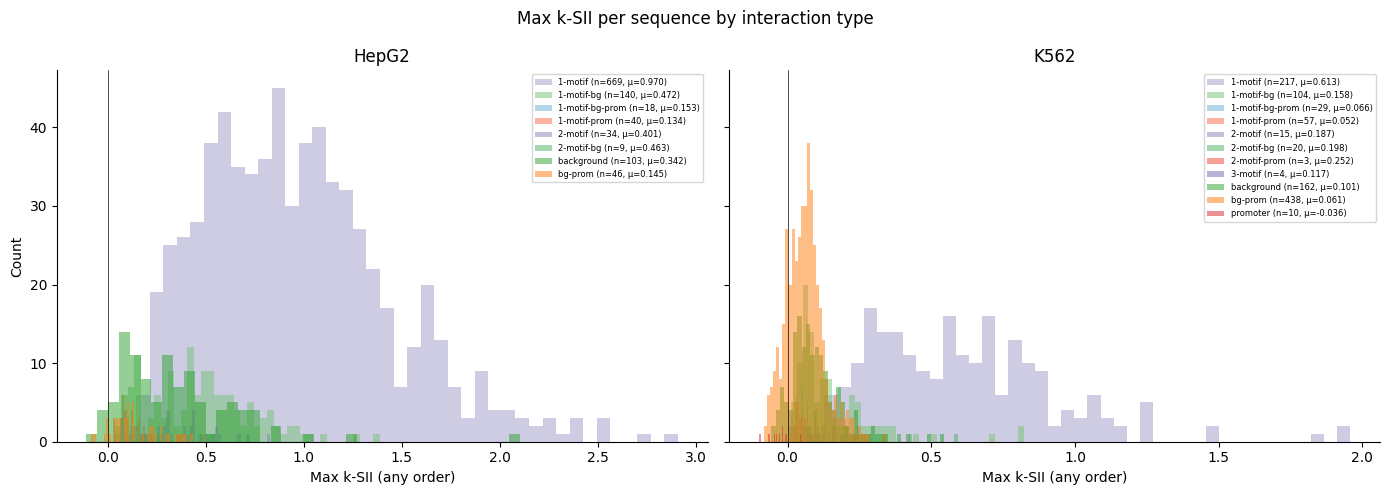

In [28]:
# Max k-SII per sequence per cell line, colored by interaction type of the max
diag = ctx_df[(ctx_df.annotation_ct == ctx_df.scoring_ct) & (ctx_df.order >= 1)]
max_rows = diag.loc[diag.groupby(['seq_idx', 'scoring_ct'])['sii_score'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ct in zip(axes, ['HepG2', 'K562']):
    sub = max_rows[max_rows.scoring_ct == ct]
    for itype in sorted(sub.itype.unique()):
        vals = sub[sub.itype == itype]['sii_score']
        ax.hist(vals, bins=40, alpha=0.5, color=itype_color(itype),
                label=f'{itype} (n={len(vals)}, μ={vals.mean():.3f})')
    ax.axvline(0, c='k', lw=0.5)
    ax.set_xlabel('Max k-SII (any order)')
    ax.set_title(ct)
    ax.legend(fontsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Count')
plt.suptitle('Max k-SII per sequence by interaction type', fontsize=12)
plt.tight_layout()
plt.show()